In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

================Data Exploration================

In [72]:
df = pd.read_csv('../data/airline_passenger_satisfaction.csv')

In [73]:
#Shape of the dataset
print(f"Shape: {df.shape}")

Shape: (129880, 24)


In [74]:
#Dataset info
print("Data types")
df.dtypes

Data types


ID                                          int64
Gender                                     object
Age                                         int64
Customer Type                              object
Type of Travel                             object
Class                                      object
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                                int64
Leg Room Service                            int64
Cleanliness                                 int64
Food and Drink                              int64
In-flight Service                           int64


In [75]:
df.describe()

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [76]:
#Missing values
print("Missing values")
df.isna().sum()
#Arrival Delay - 393 missing values.
#It is only 0.3% of whole dataset, so it can be dropped.

Missing values


ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

In [77]:
#Target distribution
print("Target distribution")
df['Satisfaction'].value_counts()

Target distribution


Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

================Data Preprocessing================

In [78]:
df = df.drop(columns=['ID']) # ID is not useful for prediction, so it can be dropped.
rows = df[df['Arrival Delay'].isna()].index
df = df.drop(index=rows) # Drop rows with missing values in 'Arrival Delay' column.

In [79]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
LE = LabelEncoder()
OHE = OneHotEncoder()

label_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Satisfaction']
one_hot_cols = ['Class']
for col in label_cols:
    df[col] = LE.fit_transform(df[col])
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)
df[['Class_Economy', 'Class_Economy Plus']] = df[['Class_Economy', 'Class_Economy Plus']].astype(int)    

In [80]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129487 non-null  int64  
 1   Age                                     129487 non-null  int64  
 2   Customer Type                           129487 non-null  int64  
 3   Type of Travel                          129487 non-null  int64  
 4   Flight Distance                         129487 non-null  int64  
 5   Departure Delay                         129487 non-null  int64  
 6   Arrival Delay                           129487 non-null  float64
 7   Departure and Arrival Time Convenience  129487 non-null  int64  
 8   Ease of Online Booking                  129487 non-null  int64  
 9   Check-in Service                        129487 non-null  int64  
 10  Online Boarding                         129487 no

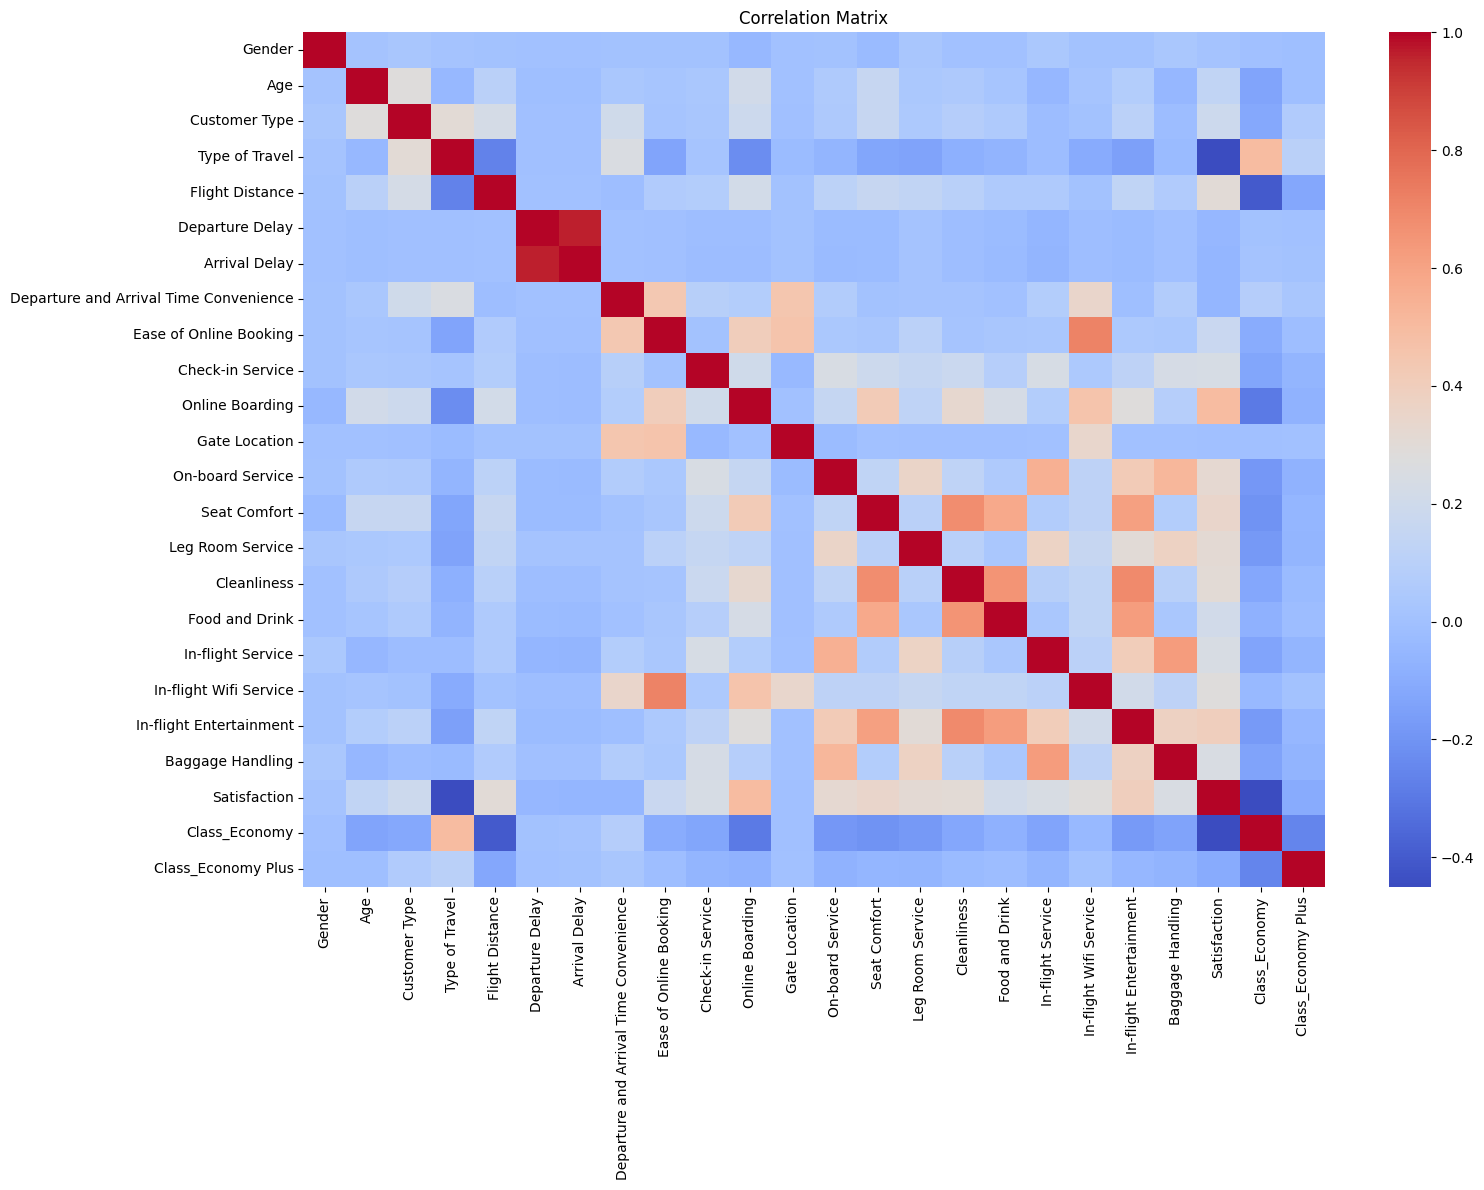

In [81]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Departure Delay and Arrival Delay are highly correlated, so we can drop one of them. In this case, we will drop Departure Delay, because Arrival Delay is more informative for our analysis.

In [82]:
df = df.drop(columns=['Departure Delay'])

In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['Age', 'Flight Distance', 'Arrival Delay']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.describe()

,Gender,Age,Customer Type,Type of Travel,Flight Distance,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,...,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Class_Economy,Class_Economy Plus
count,129487.000000,1.294870e+05,129487.000000,129487.000000,1.294870e+05,1.294870e+05,129487.000000,129487.000000,129487.000000,129487.000000,...,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,0.492590,-2.118124e-16,0.816862,0.309236,-1.088694e-16,6.145851e-18,3.057349,2.756786,3.306239,3.252720,...,3.351078,3.286222,3.204685,3.642373,2.728544,3.358067,3.631886,0.434499,0.448825,0.072440
std,0.499947,1.000004e+00,0.386781,0.462180,1.000004e+00,1.000004e+00,1.526787,1.401662,1.266146,1.350651,...,1.316132,1.313624,1.329905,1.176614,1.329235,1.334149,1.180082,0.495693,0.497376,0.259216
min,0.000000,-2.145109e+00,0.000000,0.000000,-1.162049e+00,-3.923289e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,-8.221419e-01,1.000000,0.000000,-7.781115e-01,-3.923289e-01,2.000000,2.000000,3.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000
50%,0.000000,3.778650e-02,1.000000,0.000000,-3.470585e-01,-3.923289e-01,3.000000,3.000000,3.000000,3.000000,...,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000
75%,1.000000,7.654182e-01,1.000000,1.000000,5.551455e-01,-5.436375e-02,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000,1.000000,1.000000,0.000000
max,1.000000,3.014462e+00,1.000000,1.000000,3.802077e+00,4.078743e+01,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000
